In [34]:
# ============================================================
# CLASIFICADOR BINARIO UTILIZANDO EL ALGORITMO PERCEPTRÓN
#
# Nombre: Tania Pamela Apaza Vilca
#
# Dataset:
# Breast Cancer Wisconsin (Scikit-Learn): contiene 30 características obtenidas de imágenes microscópicas de un tumor mamario.
#
# Interpretación de clases:
# 0 -> No sobrevive (Tumor cancerígeno)
# 1 -> Sobrevive (Tumor no cancerígeno)
# ============================================================

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
# Carga del dataset

data = load_breast_cancer()

# Matriz de características
X = data.data

# Vector de clases
y = data.target

In [4]:
# El DataFrame para visualizar mejor la información

df = pd.DataFrame(X, columns=data.feature_names)

# Agregar la clase

df["Clase"] = y

# Cambiar nombres de las clases

df["Clase"] = df["Clase"].replace({
    0: "No sobrevive",
    1: "Sobrevive"
})

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Clase
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,No sobrevive
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,No sobrevive
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,No sobrevive
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,No sobrevive
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,No sobrevive


In [5]:
print("Cantidad de registros:", X.shape[0])

print("Cantidad de características:", X.shape[1])

print("Forma de la matriz:", X.shape)

print("Forma del vector:", y.shape)

Cantidad de registros: 569
Cantidad de características: 30
Forma de la matriz: (569, 30)
Forma del vector: (569,)


In [7]:
# Crear un vector de pesos inicial

pesos = np.zeros(X.shape[1])

print("Vector de pesos")

print(pesos)

Vector de pesos
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]


In [8]:
# Producto punto entre el primer registro y el vector de pesos

resultado = np.dot(X[0], pesos)

print("Producto punto:")

print(resultado)

Producto punto:
0.0


In [ ]:
#El perceptrón multiplica cada característica por un peso, suma todos los resultados mediante el producto punto y, con base en ese valor, decide a qué clase pertenece el registro.

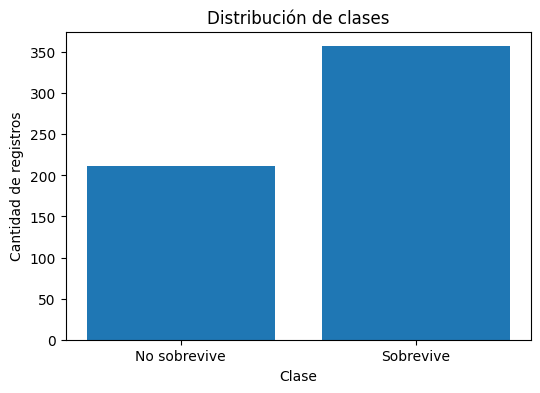

In [9]:
conteo = pd.Series(y).value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    ["No sobrevive", "Sobrevive"],
    conteo.sort_index()
)

plt.title("Distribución de clases")

plt.xlabel("Clase")

plt.ylabel("Cantidad de registros")

plt.show()

In [10]:
#Dividimos el dataset en dos partes  Datos de entrenamiento (Train)/ Datos de prueba (Test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [11]:
#Normalización
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [12]:
print("Entrenamiento")

print(X_train.shape)

print("\n")

print("Prueba")

print(X_test.shape)

Entrenamiento
(455, 30)


Prueba
(114, 30)


In [ ]:
#ENTRENAMIENTO

In [18]:
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=30):

        # Tasa de aprendizaje
        self.learning_rate = learning_rate

        # Número de veces que recorrerá el dataset
        self.epochs = epochs

        # Vector de pesos
        self.weights = None

        # Bias (sesgo)
        self.bias = 0

        # Lista para guardar errores por época
        self.errors = []

    #Función de activación
    def activation(self, x):

      if x >= 0:
          return 1
      else:
          return 0


    #Método de entrenamiento (fit)
    def fit(self, X, y):

      # Cantidad de características
      n_features = X.shape[1]

      # Inicializar pesos en cero
      self.weights = np.zeros(n_features)

      # Inicializar bias
      self.bias = 0

      # Entrenamiento
      for epoch in range(self.epochs):

          errores = 0

          # Recorrer cada registro
          for xi, target in zip(X, y):

              # Producto punto
              linear_output = np.dot(xi, self.weights) + self.bias

              # Predicción
              prediction = self.activation(linear_output)

              # Error
              update = self.learning_rate * (target - prediction)

              # Actualizar pesos
              self.weights += update * xi

              # Actualizar bias
              self.bias += update

              # Contar errores
              if update != 0:
                  errores += 1

          # Guardar errores de la época
          self.errors.append(errores)

    #Método predict para clasificar nuevos pacientes
    def predict(self, X):

      linear_output = np.dot(X, self.weights) + self.bias

      predictions = []

      for value in linear_output:
          predictions.append(self.activation(value))

      return np.array(predictions)

In [ ]:
"""
¿CÓMO FUNCIONA EL PERCEPTRÓN?

1. Inicializa todos los pesos en cero.
2. Recorre cada registro del conjunto de entrenamiento.
3. Calcula la suma ponderada (producto punto).
4. Aplica una función de activación.
5. Si la predicción es incorrecta, actualiza los pesos.
6. Repite el proceso durante varias épocas.

Fórmula:

Salida = X·W + b

donde:

X = vector de características
W = vector de pesos
b = sesgo (bias)
"""

In [19]:
#Creamos el modelo
modelo = Perceptron(
    learning_rate=0.01,
    epochs=30
)

In [20]:
#Entrenamos el modelo
modelo.fit(X_train, y_train)

In [ ]:
#Al inicio todos los pesos valen cero.

#Después de cada error el Perceptrón ajusta los pesos.

In [21]:
print("Pesos aprendidos:")

print(modelo.weights)

Pesos aprendidos:
[ 0.01172551  0.05792806  0.01961605  0.00773996  0.00433284  0.09006018
 -0.10687613 -0.13270692  0.04854897 -0.02305924 -0.1248231   0.0139723
 -0.00039273 -0.13604317 -0.1145845  -0.0360865   0.18815376 -0.02865501
  0.07791835  0.05618232 -0.0624537  -0.13760258 -0.00699896 -0.06606817
  0.03083119  0.0088107  -0.15495328 -0.08128086 -0.15307145  0.06972752]


In [22]:
print("Bias aprendido:")

print(modelo.bias)

Bias aprendido:
0.009999999999999997


In [23]:
#Errores por época
print(modelo.errors)

[28, 22, 16, 17, 15, 15, 12, 9, 13, 8, 13, 13, 12, 10, 10, 16, 12, 15, 15, 12, 12, 14, 11, 13, 11, 8, 15, 9, 7, 10]


In [24]:
#EVALUACIÓN DEL MODELO
# Realizar predicciones

y_pred = modelo.predict(X_test)

print("Primeras 10 predicciones:")

print(y_pred[:10])

Primeras 10 predicciones:
[1 0 0 1 1 0 0 0 0 1]


In [25]:
# Comparar resultados

comparacion = pd.DataFrame({
    "Valor real": y_test,
    "Predicción": y_pred
})

comparacion.head(10)

,Valor real,Predicción
0,1,1
1,0,0
2,0,0
3,1,1
4,1,1
5,0,0
6,0,0
7,0,0
8,1,0
9,1,1


In [26]:
#porcentaje de registros clasificados correctamente.
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy del modelo: {accuracy:.2%}")

Accuracy del modelo: 96.49%


In [27]:
#Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

print("Matriz de Confusión")

print(cm)

Matriz de Confusión
[[42  1]
 [ 3 68]]


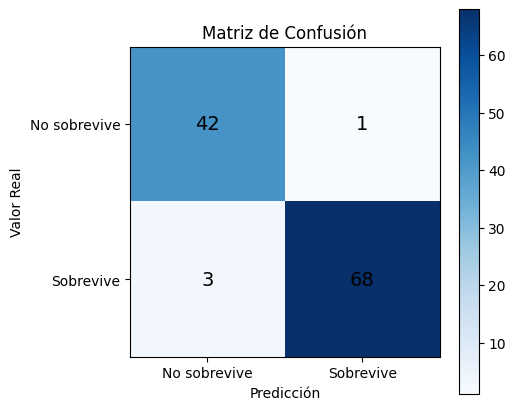

In [28]:
#Visualizar la Matriz de Confusión
plt.figure(figsize=(5,5))

plt.imshow(cm, cmap="Blues")

plt.title("Matriz de Confusión")

plt.colorbar()

plt.xticks([0,1], ["No sobrevive", "Sobrevive"])

plt.yticks([0,1], ["No sobrevive", "Sobrevive"])

plt.xlabel("Predicción")

plt.ylabel("Valor Real")

# Escribir los números dentro de cada celda

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            color="black",
            fontsize=14
        )

plt.show()

In [29]:
#Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=["No sobrevive", "Sobrevive"]
))

              precision    recall  f1-score   support

No sobrevive       0.93      0.98      0.95        43
   Sobrevive       0.99      0.96      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [30]:
aciertos = comparacion[
    comparacion["Valor real"] == comparacion["Predicción"]
]

print("Cantidad de aciertos:")

print(len(aciertos))

aciertos.head()

Cantidad de aciertos:
110


,Valor real,Predicción
0,1,1
1,0,0
2,0,0
3,1,1
4,1,1


In [32]:
errores = comparacion[
    comparacion["Valor real"] != comparacion["Predicción"]
]

print("Cantidad de errores:")

print(len(errores))

errores.head()

Cantidad de errores:
4


,Valor real,Predicción
8,1,0
20,0,1
44,1,0
112,1,0


In [33]:
print("RESUMEN DEL MODELO")

print("="*40)

print(f"Registros de prueba : {len(y_test)}")

print(f"Aciertos            : {len(aciertos)}")

print(f"Errores             : {len(errores)}")

print(f"Accuracy            : {accuracy:.2%}")

print("="*40)

RESUMEN DEL MODELO
Registros de prueba : 114
Aciertos            : 110
Errores             : 4
Accuracy            : 96.49%


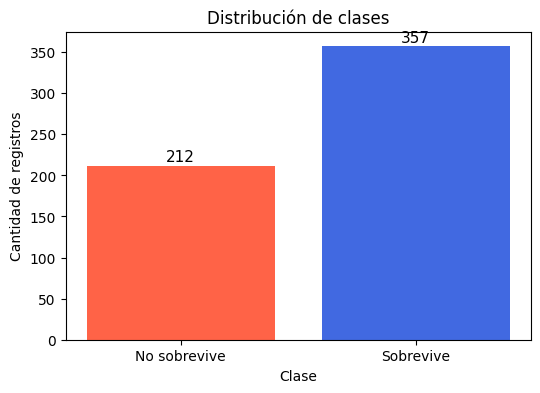

In [35]:
#GRAFICOS: DISTRIBUCIÓN DE CLASES
# Contar la cantidad de registros por clase

conteo = pd.Series(y).value_counts().sort_index()

plt.figure(figsize=(6,4))

plt.bar(
    ["No sobrevive", "Sobrevive"],
    conteo,
    color=["tomato","royalblue"]
)

plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad de registros")

for i, valor in enumerate(conteo):
    plt.text(i, valor+5, str(valor), ha="center", fontsize=11)

plt.show()

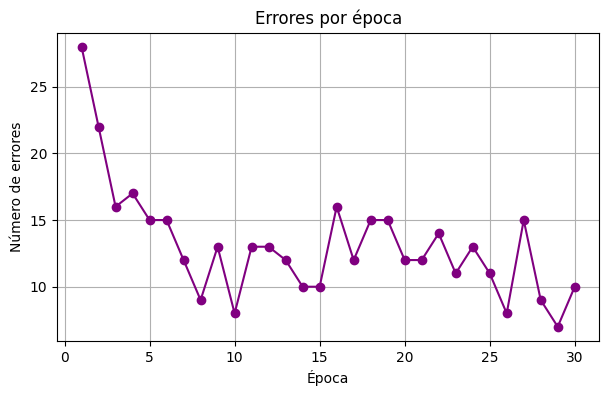

In [36]:
#Evolución del error
plt.figure(figsize=(7,4))

plt.plot(
    range(1, len(modelo.errors)+1),
    modelo.errors,
    marker="o",
    color="purple"
)

plt.title("Errores por época")

plt.xlabel("Época")

plt.ylabel("Número de errores")

plt.grid(True)

plt.show()

In [37]:
#Reducción de dimensiones con PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_test)

print("Dimensión original:", X_test.shape)

print("Nueva dimensión:", X_pca.shape)

Dimensión original: (114, 30)
Nueva dimensión: (114, 2)


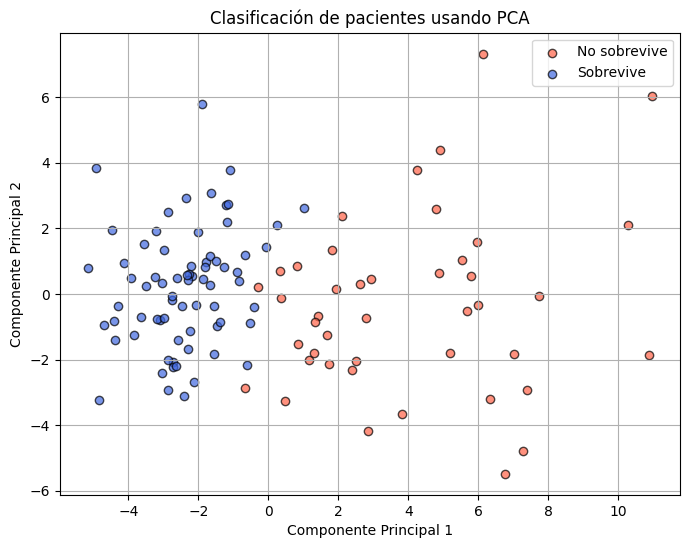

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[y_test==0,0],
    X_pca[y_test==0,1],
    color="tomato",
    edgecolor="black",
    alpha=0.7,
    label="No sobrevive"
)

plt.scatter(
    X_pca[y_test==1,0],
    X_pca[y_test==1,1],
    color="royalblue",
    edgecolor="black",
    alpha=0.7,
    label="Sobrevive"
)

plt.title("Clasificación de pacientes usando PCA")

plt.xlabel("Componente Principal 1")

plt.ylabel("Componente Principal 2")

plt.legend()

plt.grid(True)

plt.show()

In [39]:
# Reducimos los datos de entrenamiento y prueba con PCA
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Entrenar un Perceptrón solo para visualización
modelo_pca = Perceptron(learning_rate=0.01, epochs=30)
modelo_pca.fit(X_train_pca, y_train)

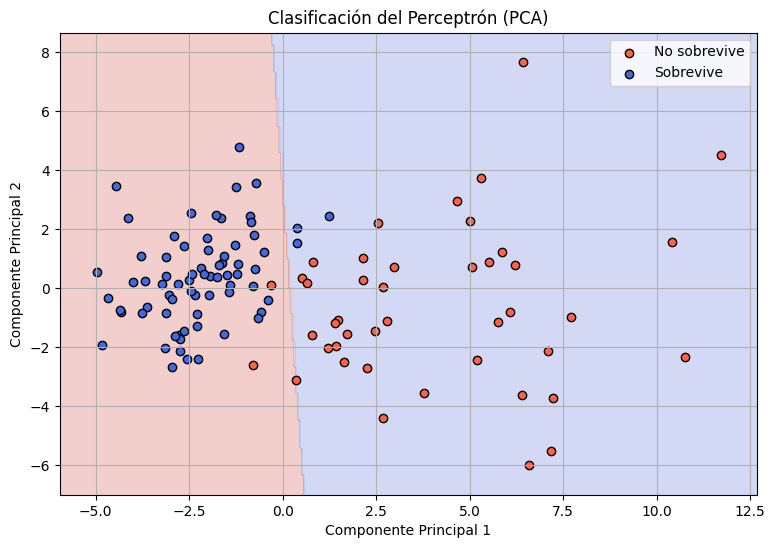

In [40]:
# Crear una malla de puntos

x_min, x_max = X_test_pca[:,0].min()-1, X_test_pca[:,0].max()+1
y_min, y_max = X_test_pca[:,1].min()-1, X_test_pca[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.05),
    np.arange(y_min, y_max, 0.05)
)

# Clasificar todos los puntos de la malla

Z = modelo_pca.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(9,6))

# Fondo coloreado
plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")

# Pacientes

plt.scatter(
    X_test_pca[y_test==0,0],
    X_test_pca[y_test==0,1],
    color="tomato",
    edgecolor="black",
    label="No sobrevive"
)

plt.scatter(
    X_test_pca[y_test==1,0],
    X_test_pca[y_test==1,1],
    color="royalblue",
    edgecolor="black",
    label="Sobrevive"
)

plt.title("Clasificación del Perceptrón (PCA)")

plt.xlabel("Componente Principal 1")

plt.ylabel("Componente Principal 2")

plt.legend()

plt.grid(True)

plt.show()

In [41]:
# Elegimos un paciente del conjunto de prueba

paciente = X_test[10]

prediccion = modelo.predict(paciente.reshape(1,-1))[0]

print("Predicción del modelo")

if prediccion == 1:
    print("Sobrevive")
else:
    print("No sobrevive")

Predicción del modelo
Sobrevive


In [42]:
registro = pd.DataFrame(
    paciente.reshape(1,-1),
    columns=data.feature_names
)

registro

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-0.25698,1.423262,-0.320319,-0.32852,-0.563287,-0.983907,-0.770695,-0.725962,-0.699225,-0.960424,...,-0.392241,1.435074,-0.474328,-0.430452,-0.114157,-0.945739,-0.648257,-0.829558,-0.730832,-0.896769
